# Testlauf Zeitreihenanalyse mit Pyhton

## Daten einlesen (Vektor & Raster)
- Vektor: Polygon mit der AOI
- Raster: eine Sentinel-2 Szene zu beginn

### Vektordaten

- Vektordatenset einlesen
- AOI herausfiltern
- plotten

In [1]:
# library laden
import geopandas as gpd
import fiona  # braucht es um Layer des GeoPackages anzuzeigen

In [2]:
# Pfad zum GeoPackage
gpkg_path = "Data_Natura2000/Natura2000_end2024.gpkg"

In [3]:
# Alle Layer auflisten
layers = fiona.listlayers(gpkg_path)
print(layers)

['NaturaSite_polygon', 'BIOREGION', 'DESIGNATIONSTATUS', 'HABITATS', 'HABITATCLASS', 'NATURA2000SITES', 'OTHERSPECIES', 'METADATA', 'IMPACT', 'MANAGEMENT', 'SPECIES']


In [4]:
# Layer auswählen
natura_sites = gpd.read_file(gpkg_path, layer="NaturaSite_polygon")

In [5]:
# Anschauen, welche Informationen sich in aoi befinden
print(natura_sites)

        SITECODE                  SITENAME  MS SITETYPE INSPIRE_ID  \
0      SE0320228                  Lunnarna  SE        C              
1      SE0340103               Kallgatburg  SE        B              
2      SE0430147  Jonstorp-Vegeåns mynning  SE        B              
3      SE0820084                  Åträsket  SE        B              
4      SE0110366                        Ön  SE        B              
...          ...                       ...  ..      ...        ...   
27168  SE0340125                  Högklint  SE        B              
27169  SE0720321               Bötelsmyren  SE        B              
27170  SE0710060                 Prästflon  SE        B              
27171  SE0410122                 Grimsmåla  SE        B              
27172  SE0230249              Kushults äng  SE        B              

                                                geometry  
0      POLYGON ((4524927.242 3742218.657, 4525316.92 ...  
1      POLYGON ((4837612.182 3874303.987,

In [6]:
# Nach Gebiet filtern
aoi_fagaras = natura_sites[natura_sites['SITECODE'] == 'ROSAC0122'] # Info aus der Map aus
# https://natura2000.eea.europa.eu/?views=Blank_View#data_s=id%3AdataSource_7-Layman_sites_2246%3A21420
#### meine AOI: Munții Făgăraș (Făgăraș-Gebirge) ####

In [7]:
# Kontrolle
print(aoi_fagaras)

        SITECODE        SITENAME  MS SITETYPE INSPIRE_ID  \
12291  ROSAC0122  Munții Făgăraș  RO        B              

                                                geometry  
12291  POLYGON ((5453305.736 2580764.134, 5453320.951...  


In [8]:
aoi_fagaras.explore()
# die Basemap kommt nur, wenn ein crs (Koordinatensystem) gesetzt ist! Falls diese fehlt --> crs setzen

In [9]:
# Polygon als GeoJSON abspeichern, um damit Rasterdaten zu suchen

aoi_fagaras.to_file("aoi.geojson", driver="GeoJSON")

### Rasterdaten
- benötigte Bänder einlesen

In [10]:
# alle Bänder in einem Ordner (hier 20m resolution) anzeigen

import os
os.listdir("S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R20m")

['T35TLL_20250626T092051_AOT_20m.jp2',
 'T35TLL_20250626T092051_B01_20m.jp2',
 'T35TLL_20250626T092051_B02_20m.jp2',
 'T35TLL_20250626T092051_B03_20m.jp2',
 'T35TLL_20250626T092051_B04_20m.jp2',
 'T35TLL_20250626T092051_B05_20m.jp2',
 'T35TLL_20250626T092051_B06_20m.jp2',
 'T35TLL_20250626T092051_B07_20m.jp2',
 'T35TLL_20250626T092051_B11_20m.jp2',
 'T35TLL_20250626T092051_B12_20m.jp2',
 'T35TLL_20250626T092051_B8A_20m.jp2',
 'T35TLL_20250626T092051_SCL_20m.jp2',
 'T35TLL_20250626T092051_TCI_20m.jp2',
 'T35TLL_20250626T092051_WVP_20m.jp2']

In [11]:
# Pfad im Ordner angeben, wo die Bänder abgelegt sind (hier red und nir für NDVI + SCL-Layer für Wolkenmaskierung)
red_path = "S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R10m/T35TLL_20250626T092051_B04_10m.jp2" 
nir_path = "S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R10m/T35TLL_20250626T092051_B08_10m.jp2"
scl_path = "S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R20m/T35TLL_20250626T092051_SCL_20m.jp2"

In [12]:
# Bänder einlesen
import rasterio

with rasterio.open(red_path) as band_red:
    red = band_red.read(1)

with rasterio.open(nir_path) as band_nir:
    nir = band_nir.read(1)

with rasterio.open(scl_path) as band_scl:
    scl = band_scl.read(1)

## Koordinatensystem abgleichen
wenn ich den Raster auf das Polygon zuschneiden will, müssen alle im gleichen Koordinatensystem vorliegen!!

In [15]:
print(aoi_fagaras.crs)
print(band_nir.crs)
print(band_red.crs)
print(band_scl.crs)

EPSG:3035
EPSG:32635
EPSG:32635
EPSG:32635


In [16]:
# Koordinatensystem an jenes der Sentinel-2 Daten anpassen (EPSG 32635 = UTM Zone 35N)
aoi_fagaras = aoi_fagaras.to_crs(band_nir.crs)
print(aoi_fagaras.crs)

PROJCS["WGS 84 / UTM zone 35N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",27],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32635"]]


## Raster auf Polygon clippen

In [17]:
# libraries laden
from rasterio.mask import mask 
import rasterio
import fiona

In [22]:
# NIR-Band zuschneiden
with rasterio.open(nir_path) as src:
    nir_clip, nir_transform = mask(src, aoi_fagaras.geometry, crop=True)

# RED-Band zuschneiden
with rasterio.open(red_path) as src:
    red_clip, red_transform = mask(src, aoi_fagaras.geometry, crop=True)

# SCL-Band zuschneiden
with rasterio.open(scl_path) as src:
    scl_clip, scl_transform = mask(src, aoi_fagaras.geometry, crop=True)

In [23]:
# Arrays auf 2D reduzieren
# ohne das Reduzieren auf 3D ist der Array: (Bänder, Höhe, Breite)
# wenn ich nur 1 Band habe brauche ich diese Information nicht --> 2D: (Höhe, Breite)
# mit [0] wähle ich das 1. Band aus; mit [2] würde ich das 3. Band auswählen etc.
nir_clip = nir_clip[0]
red_clip = red_clip[0]
scl_clip = scl_clip[0]

In [24]:
# Kontrolle --> Shape anschauen
print(nir_clip.shape) # --> 2D
print(red_clip.shape) # --> 2D
print(scl_clip.shape) # --> 2D (PS: hat nur die Hälfte der Pixel da 20m Auflösung, NIR und RED haben 10m)

(4550, 6245)
(4550, 6245)
(2275, 3123)


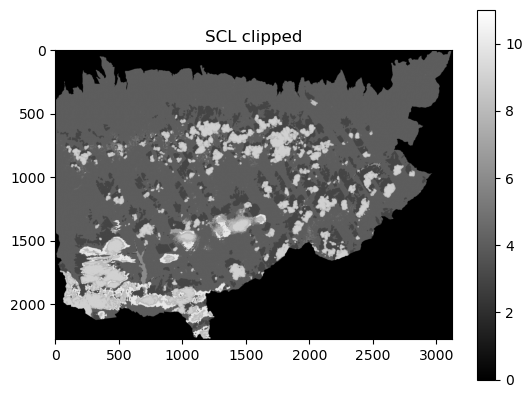

In [26]:
import matplotlib.pyplot as plt

plt.imshow(scl_clip, cmap="gray")
plt.title("SCL clipped")
plt.colorbar()

# dann anzeigen
plt.show()

## Wolkenmaskierung

### SCL-Raster resampeln auf 10m (SCL = 20m Auflösung)

In [28]:
import rasterio
from rasterio.enums import Resampling

upscale_factor = 2 # den kann man sicher noch automatisch berechnen (grösseres / kleineres oder so)

with rasterio.open(scl_clip) as src:

    # resample data to target shape
    scl = src.read(
        out_shape=(
            src.count,
            int(src.height * upscale_factor),
            int(src.width * upscale_factor)
        ),
        resampling=Resampling.enums.Resampling.nearest
    )

    # scale image transform
    transform = src.transform * dataset.transform.scale(
        (src.width / scl.shape[-1]),
        (src.height / scl.shape[-2])
    )

TypeError: invalid path or file: array([[0, 0, 0, ..., 4, 0, 0],
       [0, 0, 0, ..., 4, 0, 0],
       [0, 0, 0, ..., 4, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2275, 3123), dtype=uint8)

In [19]:
from rasterio.enums import Resampling

with rasterio.open(scl_path) as src:
    scl = src.read(
        1,
        out_shape=(
            src.height * 2,  # Faktor 2: 20m → 10m
            src.width * 2
        ),
        resampling=rasterio.enums.Resampling.nearest
    )


# 2. Danach resamplen (auf 2x Auflösung)
scale = 2

new_height = scl_clip.shape[1] * scale
new_width  = scl_clip.shape[2] * scale

scl_resampled = rasterio.warp.resample(
    scl_clip,
    out_shape=(1, new_height, new_width),
    resampling=Resampling.nearest
)

AttributeError: module 'rasterio.warp' has no attribute 'resample'

In [34]:
print(scl.shape) # hat nun die doppelte Anzahl Pixel

(10980, 10980)


In [36]:
# SCL-Layer auf AOI clippen
with rasterio.open(scl_path) as src:
    scl_clip, scl_transform = mask(src, aoi_fagaras.geometry, crop=True)

In [28]:
# Array auf 2D reduzieren
scl_clip = scl_clip[0]

In [29]:
print(scl_clip.shape)

(2275, 3123)
